# Exploratory Data Analysis — SPARCS Hospital Discharge Data

**Goal of this notebook:** get a solid understanding of the dataset we'll use to build a hierarchical
Bayesian model of hospital **charges** and **length of stay (LOS)**, with **facility** as a grouping
variable for partial pooling.

We'll work through the standard EDA sequence:
1. Load the data and get an overview (shape, dtypes, missingness)
2. Check for duplicates and obviously invalid values
3. Look at the grouping structure (`facility`) since this drives the hierarchical/random-effects part of the model
4. Explore each categorical predictor's distribution
5. Explore the two outcome variables (`charges`, `length_of_stay`) — including skew, since both are heavily
   right-skewed cost/duration variables that will likely need a log transform
6. Look at bivariate relationships between predictors and the outcomes
7. Summarize takeaways that will inform modeling choices (transformations, pooling, which variables to include)


## 1. Setup and Load Data

We import the libraries we'll need and load the CSV. If you're running this in Colab, upload
`sparcs_model_data_python.csv` when prompted (or point `DATA_PATH` at wherever you've placed it).

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a reasonable default size and style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# --- If running in Colab, uncomment the block below to upload the file interactively ---
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# Otherwise, set the path to the CSV directly
#DATA_PATH = "sparcs_model_data_python.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset with shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(10)

Saving sparcs_model_data_python (1) (1).csv to sparcs_model_data_python (1) (1) (1).csv
Loaded dataset with shape: 94,289 rows x 8 columns


,charges,facility,age_group,admission_type,severity_code,med_surg,ed_indicator,length_of_stay
0,41759.95,1,70 or Older,Elective,0,Not Applicable,N,5
1,26348.24,1,50 to 69,Urgent,3,Medical,N,2
2,17600.99,1,18 to 29,Emergency,2,Medical,Y,4
3,17254.86,1,30 to 49,Elective,1,Medical,N,5
4,8439.06,1,30 to 49,Elective,1,Medical,N,3
5,236702.31,1,70 or Older,Urgent,4,Medical,N,38
6,149543.53,1,70 or Older,Emergency,3,Surgical,Y,18
7,23244.28,1,0 to 17,Emergency,3,Medical,Y,6
8,45602.45,1,50 to 69,Emergency,4,Medical,N,4
9,56481.80,1,50 to 69,Emergency,2,Surgical,Y,7


## Data Overview

- **Dataset shape:** 94,289 rows × 8 columns — a large, clean dataset suitable for hierarchical modeling.
- **No missing values:** All columns have complete data (0% missing), eliminating the need for imputation.
- **0.73% duplicate rows:** 689 exact duplicate rows exist. This is minimal and expected given the coarse categorical attributes; they can be retained or dropped without materially affecting results.

## 2. Structural Overview

Before touching any values, let's understand the "shape" of the data: column types, a summary of
numeric columns, and how many unique values each categorical column has. This tells us at a glance
which columns are categorical (candidates for group-level effects or fixed-effect dummies) vs.
continuous (candidates for outcome/predictor transformations).

In [ ]:
# Data types of each column
print("Column dtypes:")
print(df.dtypes)
print()

# Quick statistical summary of numeric columns
print("Numeric summary:")
display(df.describe())
print()

# Number of unique values per column - helps identify categorical vs continuous vs ID-like columns
print("Unique value counts per column:")
print(df.nunique().sort_values())

Column dtypes:
charges           float64
facility            int64
age_group          object
admission_type     object
severity_code       int64
med_surg           object
ed_indicator       object
length_of_stay      int64
dtype: object

Numeric summary:


,charges,facility,severity_code,length_of_stay
count,9.428900e+04,94289.000000,94289.000000,94289.000000
mean,5.655596e+04,1031.898769,2.088239,6.471115
std,1.194724e+05,1282.005844,0.935130,10.259109
min,7.090000e+01,1.000000,0.000000,1.000000
25%,1.413948e+04,471.000000,1.000000,2.000000
50%,2.899722e+04,858.000000,2.000000,3.000000
75%,5.927165e+04,1293.000000,3.000000,7.000000
max,6.508308e+06,10355.000000,4.000000,120.000000



Unique value counts per column:
ed_indicator          2
med_surg              3
age_group             5
severity_code         5
admission_type        6
length_of_stay      120
facility            201
charges           92709
dtype: int64


## 3. Missing Values and Duplicates

Two basic data-quality checks:
- **Missing values**: do we need to impute or drop anything?
- **Duplicate rows**: exact duplicate records can happen legitimately in claims-style data (two patients
  with identical recorded attributes), but it's worth knowing how many there are before deciding whether
  to deduplicate.

In [ ]:
# --- Missing values ---
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("Missing values per column:")
display(missing_summary)

# --- Duplicate rows ---
n_dupes = df.duplicated().sum()
print(f"\nNumber of fully duplicated rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}% of rows)")

# NOTE: with only 8 fairly coarse columns (facility, age group, admission type, severity, etc.),
# some duplication is expected simply because two unrelated patients can share identical
# categorical attributes. We are NOT dropping these yet -- just documenting them here for
# awareness. We'll revisit whether to deduplicate when we get to modeling.

Missing values per column:


,missing_count,missing_pct
charges,0,0.0
facility,0,0.0
age_group,0,0.0
admission_type,0,0.0
severity_code,0,0.0
med_surg,0,0.0
ed_indicator,0,0.0
length_of_stay,0,0.0



Number of fully duplicated rows: 689 (0.73% of rows)


In [ ]:
import pandas as pd


# keep=False marks ALL rows in a duplicate group, including the first occurrence
# (df.duplicated() alone only flags the repeats, not the original)
dupes = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

print(f"Total rows involved in duplication: {dupes.shape[0]:,}")
dupes.head(20)

Total rows involved in duplication: 1,113


,charges,facility,age_group,admission_type,severity_code,med_surg,ed_indicator,length_of_stay
16807,653.86,330,0 to 17,Newborn,1,Medical,N,2
16810,653.86,330,0 to 17,Newborn,1,Medical,N,2
16865,653.86,330,0 to 17,Newborn,1,Medical,N,2
40019,818.65,746,0 to 17,Newborn,1,Medical,N,1
40046,818.65,746,0 to 17,Newborn,1,Medical,N,1
36061,856.22,678,0 to 17,Newborn,1,Medical,N,1
36439,856.22,678,0 to 17,Newborn,1,Medical,N,1
92816,885.00,9059,18 to 29,Urgent,1,Medical,N,1
92917,885.00,9059,18 to 29,Urgent,1,Medical,N,1
92815,885.00,9059,30 to 49,Urgent,1,Medical,N,1


## 4. Facility (Grouping Variable) Structure

Since we're building a **hierarchical/multilevel model with facility-level random effects**, it's
important to understand:
- How many distinct facilities are there?
- How many records does each facility contribute? (Unbalanced group sizes affect how much partial
  pooling helps small facilities "borrow strength" from the overall population.)

Number of distinct facilities: 201

Records-per-facility summary statistics:
count    201.000000
mean     469.099502
std       96.957259
min       32.000000
25%      500.000000
50%      500.000000
75%      500.000000
max      500.000000
dtype: float64


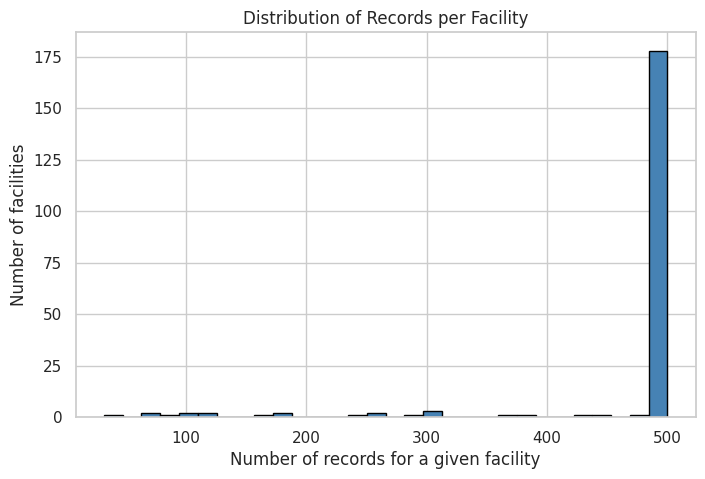

In [ ]:
n_facilities = df["facility"].nunique()
print(f"Number of distinct facilities: {n_facilities}")

# Records per facility
facility_counts = df.groupby("facility").size().sort_values(ascending=False)
print("\nRecords-per-facility summary statistics:")
print(facility_counts.describe())

# Visualize the distribution of group sizes
fig, ax = plt.subplots()
ax.hist(facility_counts, bins=30, color="steelblue", edgecolor="black")
ax.set_xlabel("Number of records for a given facility")
ax.set_ylabel("Number of facilities")
ax.set_title("Distribution of Records per Facility")
plt.show()

# NOTE: many facilities appear to be capped around the same count (likely a sampling cap
# during data extraction), while a handful have far fewer records. Those low-count facilities
# are exactly where hierarchical partial pooling will matter most.

## 5. Predictors

Our outcome variable is `charges`. Everything else — including `length_of_stay` — is a predictor.
We look at the categorical predictors (`age_group`, `admission_type`, `severity_code`, `med_surg`,
`ed_indicator`) and the one numeric predictor, `length_of_stay`, separately.

In [ ]:
categorical_cols = ["age_group", "admission_type", "severity_code", "med_surg", "ed_indicator"]

for col in categorical_cols:
    print(f"--- {col} ---")
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    summary = pd.DataFrame({"count": counts, "pct": pct})
    display(summary)
    print()

--- age_group ---


,count,pct
age_group,,
70 or Older,30558,32.41
50 to 69,27054,28.69
30 to 49,18104,19.20
0 to 17,9909,10.51
18 to 29,8664,9.19



--- admission_type ---


,count,pct
admission_type,,
Emergency,60915,64.60
Elective,18838,19.98
Newborn,7138,7.57
Urgent,7123,7.55
Trauma,177,0.19
Not Available,98,0.10



--- severity_code ---


,count,pct
severity_code,,
2,35418,37.56
1,29044,30.80
3,21722,23.04
4,7963,8.45
0,142,0.15



--- med_surg ---


,count,pct
med_surg,,
Medical,77137,81.81
Surgical,17010,18.04
Not Applicable,142,0.15



--- ed_indicator ---


,count,pct
ed_indicator,,
Y,56514,59.94
N,37775,40.06


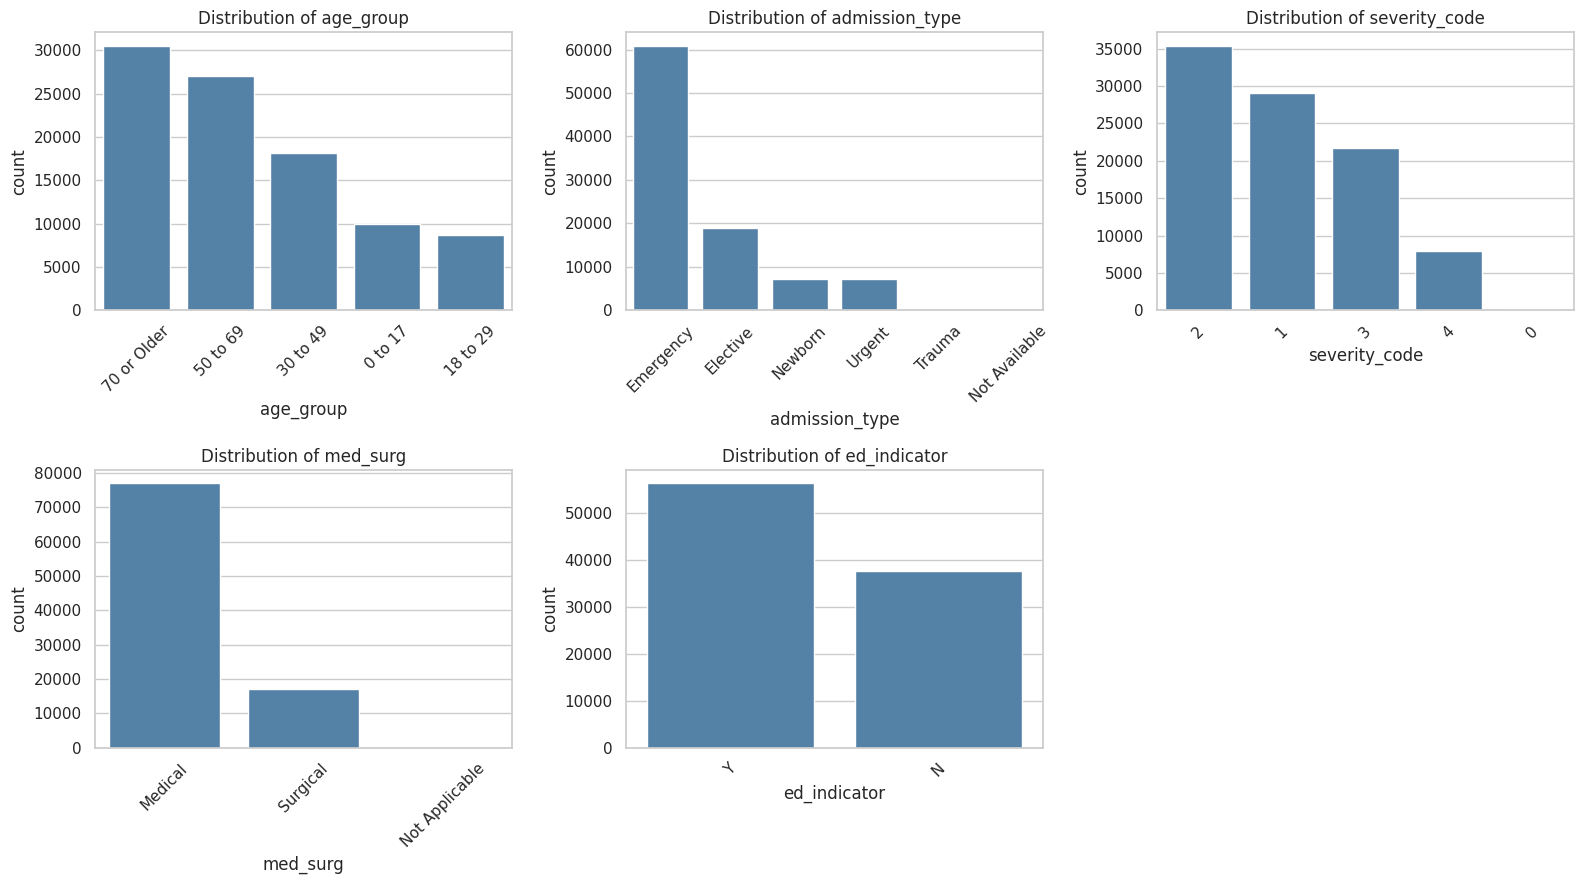

In [ ]:
# Visualize each categorical column as a bar chart
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=45)

# Remove the unused 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# NOTE: watch for small/placeholder categories such as "Not Available" (admission_type) and
# "Not Applicable" (med_surg, and severity_code == 0). These are low-frequency categories that
# may need to be grouped into "Other" or dropped depending on how much signal they carry.

### `length_of_stay` as a numeric predictor

`length_of_stay` is a count (in days) and, like most duration variables, is right-skewed - most
stays are short, with a long tail of unusually long ones. We check its raw distribution here as a
predictor (we'll revisit its relationship to `charges` in Section 7).

length_of_stay summary statistics:
count    94289.000000
mean         6.471115
std         10.259109
min          1.000000
25%          2.000000
50%          3.000000
75%          7.000000
max        120.000000
Name: length_of_stay, dtype: float64


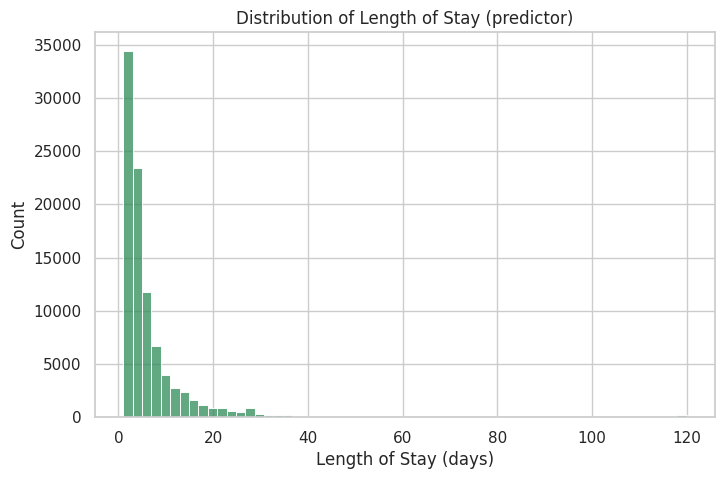

In [ ]:
# Summary statistics for length_of_stay as a predictor
print("length_of_stay summary statistics:")
print(df["length_of_stay"].describe())

fig, ax = plt.subplots()
sns.histplot(df["length_of_stay"], bins=60, ax=ax, color="seagreen")
ax.set_title("Distribution of Length of Stay (predictor)")
ax.set_xlabel("Length of Stay (days)")
plt.show()

# NOTE: like charges, length_of_stay is right-skewed. Depending on how we want to use it in the
# model (as a raw numeric predictor, log-transformed, or binned), this skew is worth keeping in
# mind -- a log transform may make its relationship with log(charges) more linear.

## 6. Outcome Variable: `charges`

`charges` is our outcome variable. Hospital cost data is almost always **right-skewed** (most
charges are modest, but a long tail of very expensive stays pulls the mean up). We check this
explicitly since it affects whether we model on the raw scale or the log scale.

In [ ]:
# Summary statistics for the outcome variable
print("Summary statistics:")
display(df[["charges"]].describe())

# Skewness and kurtosis quantify the shape of the distribution numerically
from scipy.stats import skew, kurtosis

print(f"charges: skewness = {skew(df['charges']):.2f}, kurtosis = {kurtosis(df['charges']):.2f}")

# NOTE: skewness > 1 is generally considered highly (right-)skewed. We expect charges to be well
# above that threshold, which is typical for cost data.

Summary statistics:


,charges
count,9.428900e+04
mean,5.655596e+04
std,1.194724e+05
min,7.090000e+01
25%,1.413948e+04
50%,2.899722e+04
75%,5.927165e+04
max,6.508308e+06


charges: skewness = 15.22, kurtosis = 445.88


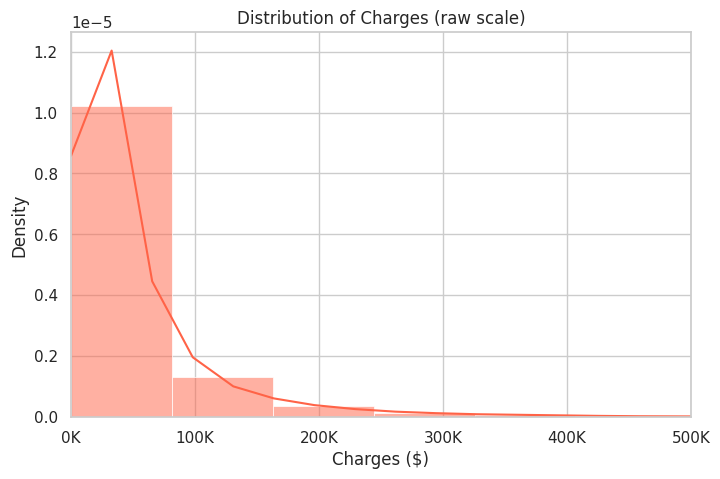

In [ ]:
# Visualize raw distribution, with x-axis capped to avoid extreme outliers squashing the plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["charges"], bins=80, ax=ax, color="tomato", kde=True, stat="density")
ax.set_title("Distribution of Charges (raw scale)")
ax.set_xlabel("Charges ($)")

# Cap the x-axis around the 99th percentile so the bulk of the distribution is visible,
# rather than being squashed by a handful of extreme outliers (max charge is ~$6.5M)
ax.set_xlim(0, 500_000)

# Format x-axis ticks in units of hundreds of thousands (e.g. "100K", "200K") instead of
# raw millions/scientific notation
import matplotlib.ticker as mticker
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}K"))

plt.show()

# NOTE: on the raw scale the distribution is dominated by a long right tail, which squashes the
# bulk of the data into a narrow bar near zero. This is the classic signature that a log
# transform will make the distribution far more workable for modeling. We cap the x-axis here
# purely for visualization -- the underlying data and later log-transform analysis still use
# the full range of charges, including the outliers beyond $500K.
#
# NOTE on kde=True: this overlays a smoothed density curve on top of the histogram bars. Since
# the KDE is fit on the FULL data (including the extreme tail beyond $500K), the curve you see
# in the plot is a cropped view of a curve that technically extends much further right -- it's
# still a useful visual guide to the shape of the bulk of the distribution. We also set
# stat="density" so the histogram bars and the KDE curve share the same y-axis scale.

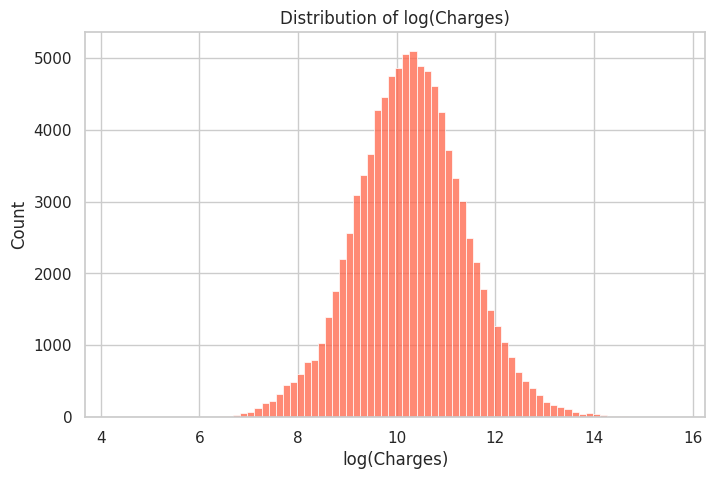

In [ ]:
# Visualize log-transformed distribution
# We use log() since charges is strictly positive here (log1p is a safer default if zeros exist)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(np.log(df["charges"]), bins=80, ax=ax, color="tomato")
ax.set_title("Distribution of log(Charges)")
ax.set_xlabel("log(Charges)")
plt.show()

# NOTE: on the log scale, charges looks much closer to a symmetric, roughly bell-shaped
# distribution. This supports modeling log(charges) as the outcome rather than the raw value --
# consistent with the log-normal-ish shape common in cost data.

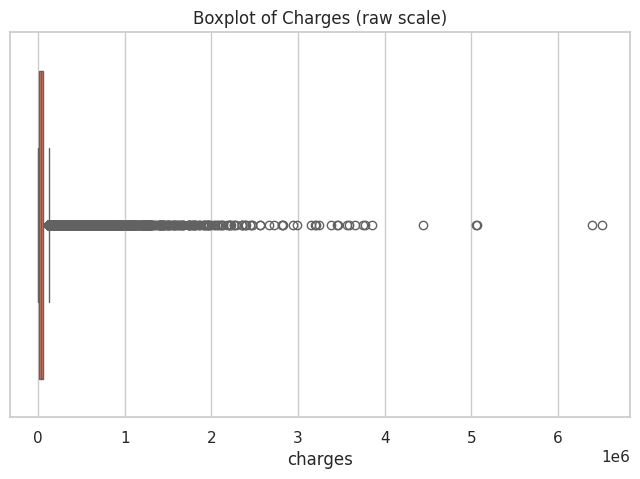

Top 5 highest charges:
82358    6508308.45
63672    6392037.76
66468    5061316.18
80393    5059582.09
63769    4439133.13


In [ ]:
# Check for extreme outliers using a boxplot (raw scale) to see how far the tail extends
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df["charges"], ax=ax, color="tomato")
ax.set_title("Boxplot of Charges (raw scale)")
plt.show()

# Report the most extreme values explicitly
print("Top 5 highest charges:")
print(df["charges"].sort_values(ascending=False).head(5).to_string())

## 7. Relationship Between `charges` (outcome) and `length_of_stay` (predictor)

Since cost typically accumulates with each additional day in the hospital, we'd expect `charges`
to increase with `length_of_stay`. We check this both numerically (correlation) and visually,
since this relationship is central to the model.

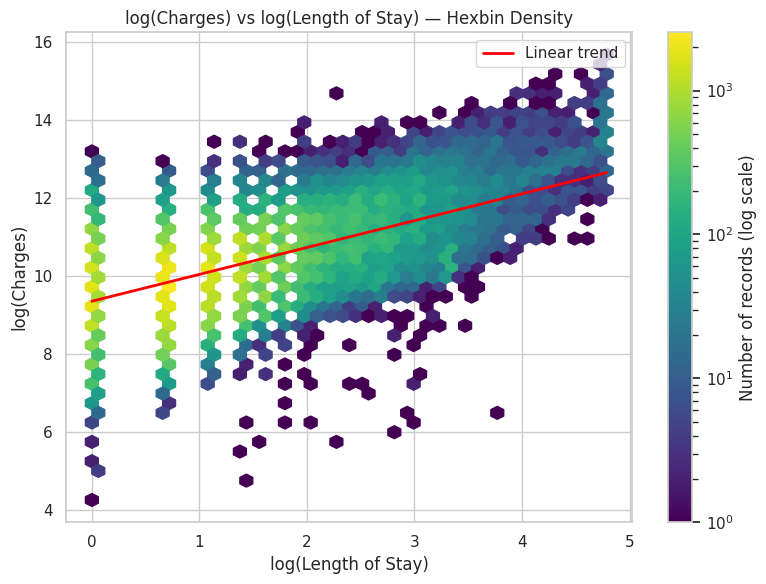

In [ ]:
# Scatter plots become heavily overplotted with ~94k points, and length_of_stay's discreteness
# creates vertical "stripes" that make the trend hard to read. A hexbin plot solves both
# problems: it bins the plane into hexagonal cells and colors each by point density, so the
# shape of the relationship is visible instead of a single dense blob.
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(
    np.log(df["length_of_stay"]),
    np.log(df["charges"]),
    gridsize=40,
    cmap="viridis",
    mincnt=1,       # don't shade empty cells
    bins="log",     # log-scale the color mapping, since a few cells (short stays) are far denser
                     # than the rest -- without this, the whole plot would look like one flat color
)

ax.set_xlabel("log(Length of Stay)")
ax.set_ylabel("log(Charges)")
ax.set_title("log(Charges) vs log(Length of Stay) — Hexbin Density")

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of records (log scale)")

# Overlay a simple linear trend line (fit on the log-log data) to make the overall
# relationship easy to read at a glance
coeffs = np.polyfit(np.log(df["length_of_stay"]), np.log(df["charges"]), 1)
xs = np.linspace(np.log(df["length_of_stay"]).min(), np.log(df["length_of_stay"]).max(), 100)
ax.plot(xs, np.polyval(coeffs, xs), color="red", linewidth=2, label="Linear trend")
ax.legend()

plt.tight_layout()
plt.show()

# NOTE: darker/purple cells = few records, green/yellow = many records. The brightest band
# sits over short stays (log(LOS) near 0-1), confirming that's where most of the data lives.
# The red trend line makes the positive log-log relationship easy to see despite the spread.

## 8. `charges` vs. Categorical Predictors

Next we look at how `charges` varies across each categorical predictor. This gives an early
signal of which predictors are likely to matter in the model, and whether the relationship looks
monotonic (e.g., does charges increase steadily with severity?).

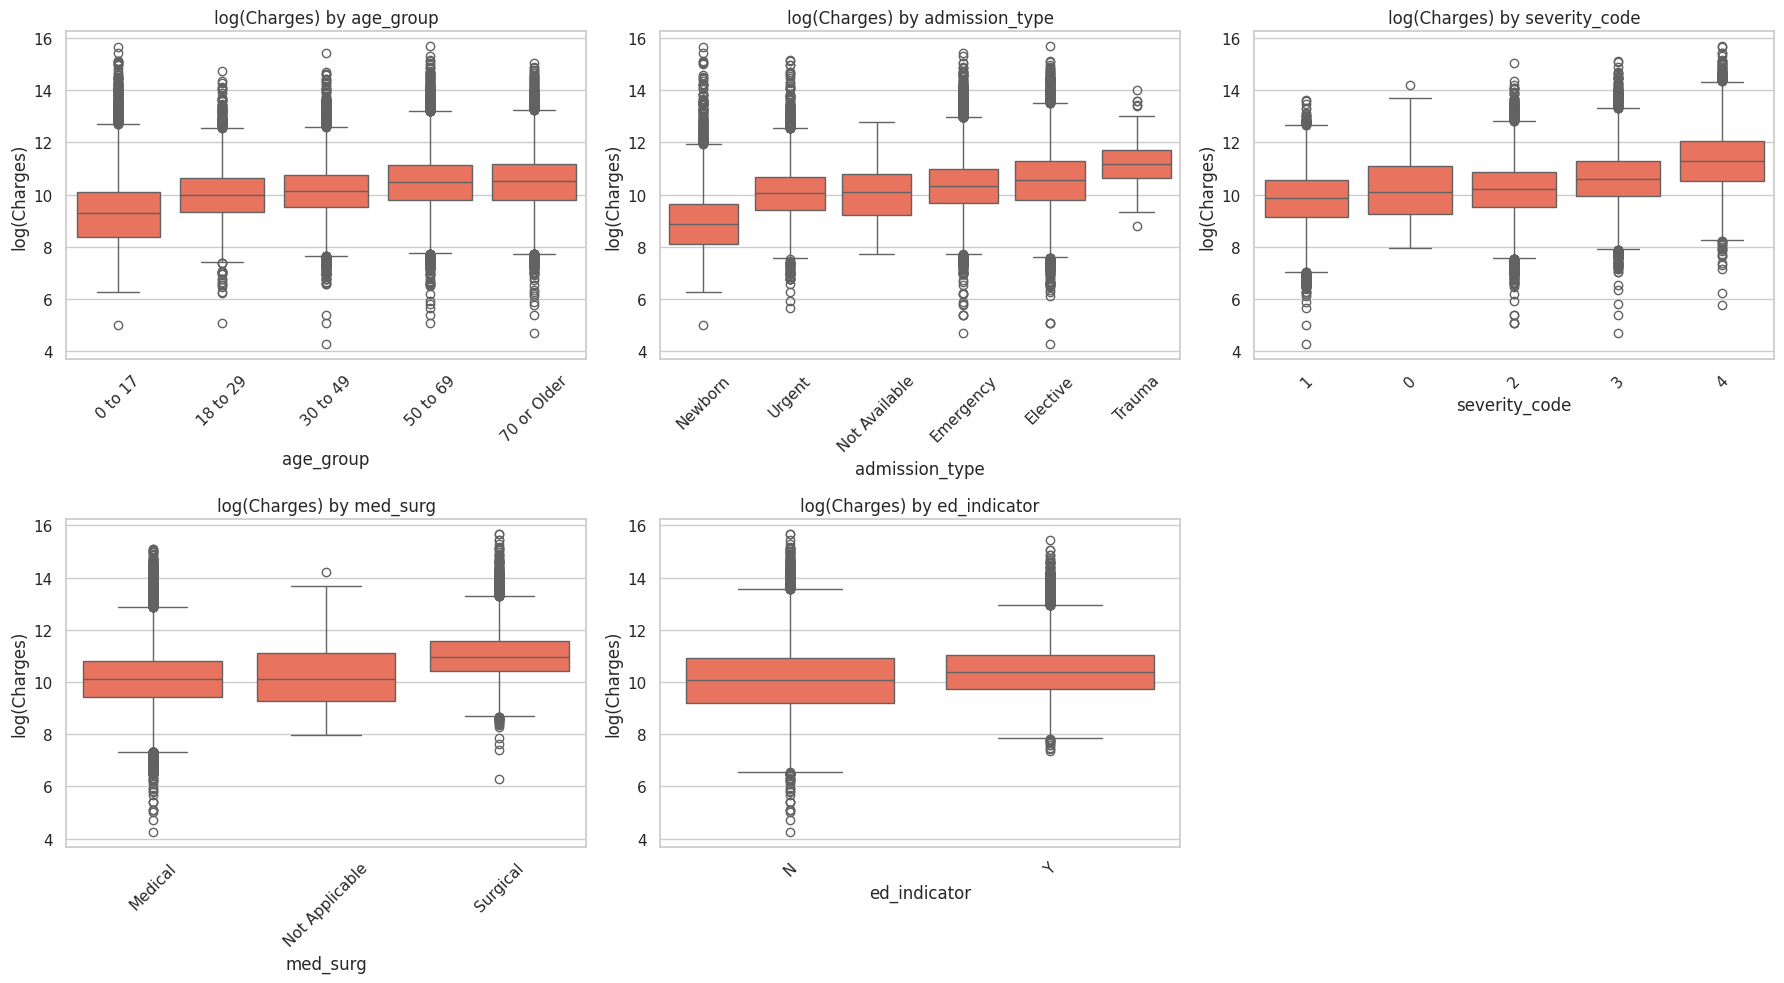

In [ ]:
# Boxplots of log(charges) by each categorical predictor
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df.groupby(col)["charges"].median().sort_values().index
    sns.boxplot(data=df, x=col, y=np.log(df["charges"]), order=order, ax=axes[i], color="tomato")
    axes[i].set_title(f"log(Charges) by {col}")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_ylabel("log(Charges)")

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 9. Facility-Level Variation in `charges`

Since facility is our grouping variable for the hierarchical model, it's worth visually
confirming that there IS meaningful variation in `charges` across facilities (otherwise partial
pooling on facility wouldn't add much). We look at the distribution of each facility's median
log(charges).

Facility-level summary (first 10 rows):


,facility,n,median_log_charges
0,1,500,10.369593
1,5,500,10.158991
2,12,500,9.059612
3,39,500,9.276197
4,42,500,9.867663
5,43,500,9.923617
6,58,500,10.049512
7,66,500,9.287152
8,85,500,9.854875
9,98,500,9.431890


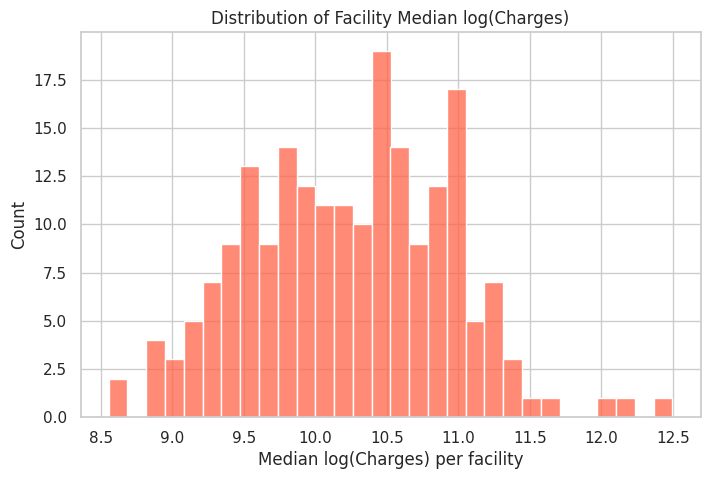

In [ ]:
# Compute per-facility median charges
facility_stats = df.groupby("facility").agg(
    n=("charges", "size"),
    median_log_charges=("charges", lambda x: np.log(x).median()),
).reset_index()

print("Facility-level summary (first 10 rows):")
display(facility_stats.head(10))

# Visualize spread of facility-level medians
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(facility_stats["median_log_charges"], bins=30, ax=ax, color="tomato")
ax.set_title("Distribution of Facility Median log(Charges)")
ax.set_xlabel("Median log(Charges) per facility")
plt.show()

# NOTE: if these medians are tightly clustered, facility may not add much to the model.
# If they're spread out, that supports including facility-level random effects.

## 10. Summary of EDA Findings

**Data quality**
- No missing values in any column.
- A modest number of exact duplicate rows exist — likely just patients sharing identical coarse
  categorical attributes rather than a data error, but worth flagging before modeling.
- A few low-frequency placeholder categories exist (`admission_type == "Not Available"`,
  `med_surg == "Not Applicable"`, `severity_code == 0`) — decide whether to keep, recode, or drop
  these before modeling.

**Grouping structure**
- 201 distinct facilities, most capped near 500 records, with a handful of facilities having far
  fewer — a good candidate for a hierarchical/partial-pooling model, since the low-count facilities
  should benefit most from borrowing strength.

**Outcome variable (`charges`)**
- Strongly right-skewed with a heavy tail and extreme outliers on the raw scale.
- A log transform makes the distribution much closer to symmetric/bell-shaped — supports
  modeling `log(charges)` rather than the raw value.

**Predictors**
- `length_of_stay` is itself right-skewed and positively associated with `charges`, especially on
  the log-log scale, as expected (cost accumulates with time in hospital).
- `severity_code`, `age_group`, `admission_type`, `med_surg`, and `ed_indicator` all show visible
  differences in median log(charges) across categories, suggesting they carry real signal for the
  model.
- Facility-level medians show spread as well, supporting the inclusion of facility as a
  hierarchical grouping factor.

**Next steps for modeling**
- Use log(charges) as the outcome.
- Decide how to include `length_of_stay` (raw vs. log-transformed) as a predictor.
- Decide how to handle placeholder/rare categories.
- Decide whether to deduplicate rows.
- Proceed to build the hierarchical Bayesian model with facility-level random effects (PyMC/Bambi
  in Colab).